In [1]:
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adicionar o diretório raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, project_root)

In [2]:
from src.utils.extract_data import get_data

## Função para graficos

In [3]:
# função para plotar graficos
def plot_bar_chart(data, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x, y=y, hue=x, palette="bwr", legend=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
qtd_entry_year = get_data("../../sql/agg_entry_year.sql")
qtd_entry_year

,Year,TotalTickets
0,2020,15687
1,2021,16233
2,2022,16049
3,2023,15828
4,2024,16266
5,2025,10658


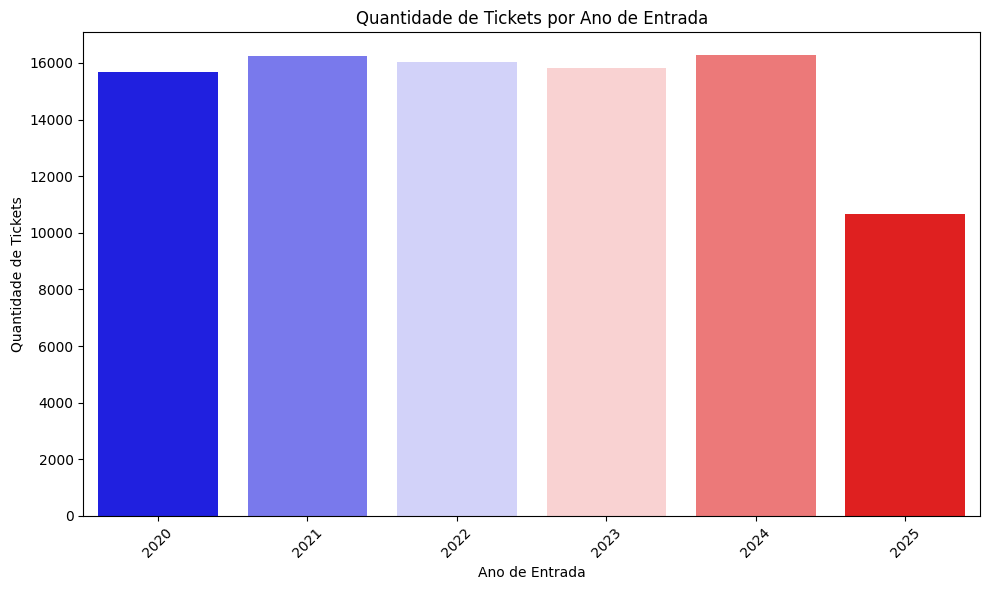

In [5]:
# quantidade de tickets por ano de entrada
plot_bar_chart(
    data=qtd_entry_year,
    x="Year",
    y="TotalTickets",
    title="Quantidade de Tickets por Ano de Entrada",
    xlabel="Ano de Entrada",
    ylabel="Quantidade de Tickets",
)

## Todas Datas de entrada por ano e mes

In [6]:
df_tickets_by_year_month = get_data("../../sql/agg_entry_year_month.sql")
df_tickets_by_year_month

,Year,Month,TotalTickets
0,2020,1,1135
1,2020,2,1283
2,2020,3,1359
3,2020,4,1315
4,2020,5,1368
...,...,...,...
63,2025,4,1314
64,2025,5,1320
65,2025,6,1287
66,2025,7,1457


In [7]:
# juntar ano e mes em uma unica coluna
df_tickets_by_year_month["YearMonth"] = (
    df_tickets_by_year_month["Year"].astype(str)
    + "-"
    + df_tickets_by_year_month["Month"].astype(str).str.zfill(2)
)
df_tickets_by_year_month

,Year,Month,TotalTickets,YearMonth
0,2020,1,1135,2020-01
1,2020,2,1283,2020-02
2,2020,3,1359,2020-03
3,2020,4,1315,2020-04
4,2020,5,1368,2020-05
...,...,...,...,...
63,2025,4,1314,2025-04
64,2025,5,1320,2025-05
65,2025,6,1287,2025-06
66,2025,7,1457,2025-07


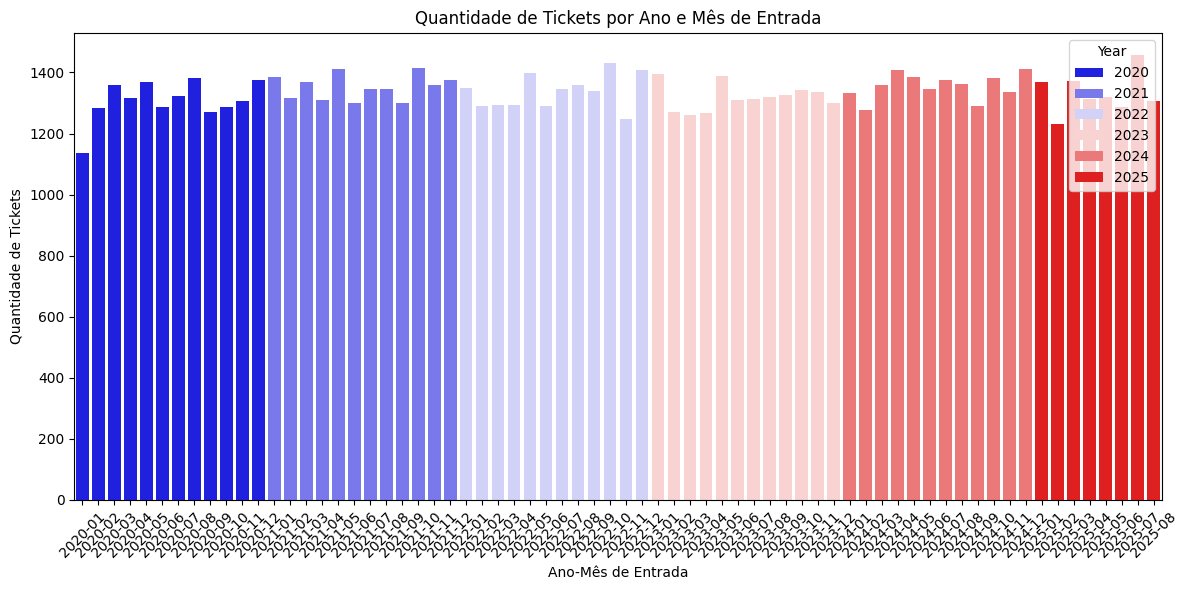

In [8]:
# mostrar grafico de barras 1 para cada ano
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_tickets_by_year_month,
    x="YearMonth",
    y="TotalTickets",
    hue="Year",
    palette="bwr",
)
plt.title("Quantidade de Tickets por Ano e Mês de Entrada")
plt.xlabel("Ano-Mês de Entrada")
plt.ylabel("Quantidade de Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Todas Datas de fechamento

In [9]:
df_all_closed_dates = get_data("../../sql/all_closed_dates_sum.sql")
df_all_closed_dates

,ClosedYear,ClosedMonth,ClosedDay,ClosedHour,ClosedMinute,TotalTickets
0,2020,1,7,4,27,1
1,2020,1,7,20,54,1
2,2020,1,8,10,41,1
3,2020,1,8,13,59,1
4,2020,1,8,19,10,1
...,...,...,...,...,...,...
46910,2025,9,6,0,45,1
46911,2025,9,6,7,28,1
46912,2025,9,6,14,28,1
46913,2025,9,6,22,49,1


In [10]:
# juntar ano, mes, dia, hora, minuto em uma unica coluna
df_all_closed_dates["ClosedDate"] = pd.to_datetime(
    df_all_closed_dates.rename(
        columns={
            "ClosedYear": "year",
            "ClosedMonth": "month",
            "ClosedDay": "day",
            "ClosedHour": "hour",
            "ClosedMinute": "minute",
        }
    )[["year", "month", "day", "hour", "minute"]]
)
df_all_closed_dates

,ClosedYear,ClosedMonth,ClosedDay,ClosedHour,ClosedMinute,TotalTickets,ClosedDate
0,2020,1,7,4,27,1,2020-01-07 04:27:00
1,2020,1,7,20,54,1,2020-01-07 20:54:00
2,2020,1,8,10,41,1,2020-01-08 10:41:00
3,2020,1,8,13,59,1,2020-01-08 13:59:00
4,2020,1,8,19,10,1,2020-01-08 19:10:00
...,...,...,...,...,...,...,...
46910,2025,9,6,0,45,1,2025-09-06 00:45:00
46911,2025,9,6,7,28,1,2025-09-06 07:28:00
46912,2025,9,6,14,28,1,2025-09-06 14:28:00
46913,2025,9,6,22,49,1,2025-09-06 22:49:00


## Tickets fechados por dia da semana

In [11]:
# Tendência ao longo do tempo
df_all_closed_dates["Year"] = df_all_closed_dates["ClosedDate"].dt.year
df_all_closed_dates["Month"] = df_all_closed_dates["ClosedDate"].dt.month
df_all_closed_dates["DayOfWeek"] = df_all_closed_dates["ClosedDate"].dt.dayofweek
df_all_closed_dates["Hour"] = df_all_closed_dates["ClosedDate"].dt.hour

In [12]:
# Tickets fechados por dia da semana
tickets_by_weekday = (
    df_all_closed_dates.groupby("DayOfWeek")["TotalTickets"].sum().reset_index()
)
days = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
tickets_by_weekday["DayName"] = tickets_by_weekday["DayOfWeek"].apply(lambda x: days[x])

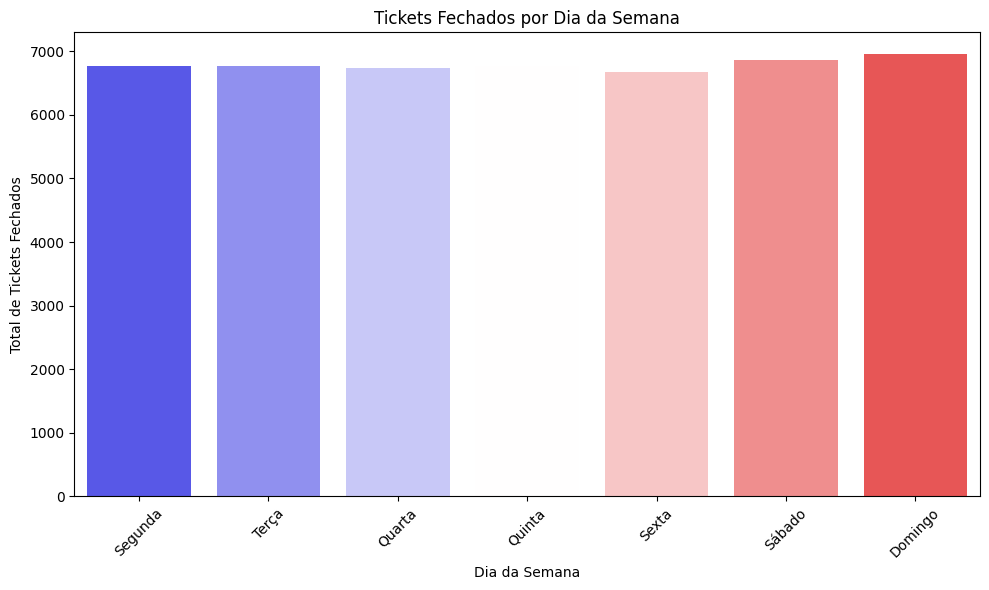

In [13]:
plot_bar_chart(
    data=tickets_by_weekday,
    x="DayName",
    y="TotalTickets",
    title="Tickets Fechados por Dia da Semana",
    xlabel="Dia da Semana",
    ylabel="Total de Tickets Fechados",
)

## Tickets fechados por hora do dia

In [14]:
tickets_by_hour = (
    df_all_closed_dates.groupby("Hour")["TotalTickets"].sum().reset_index()
)

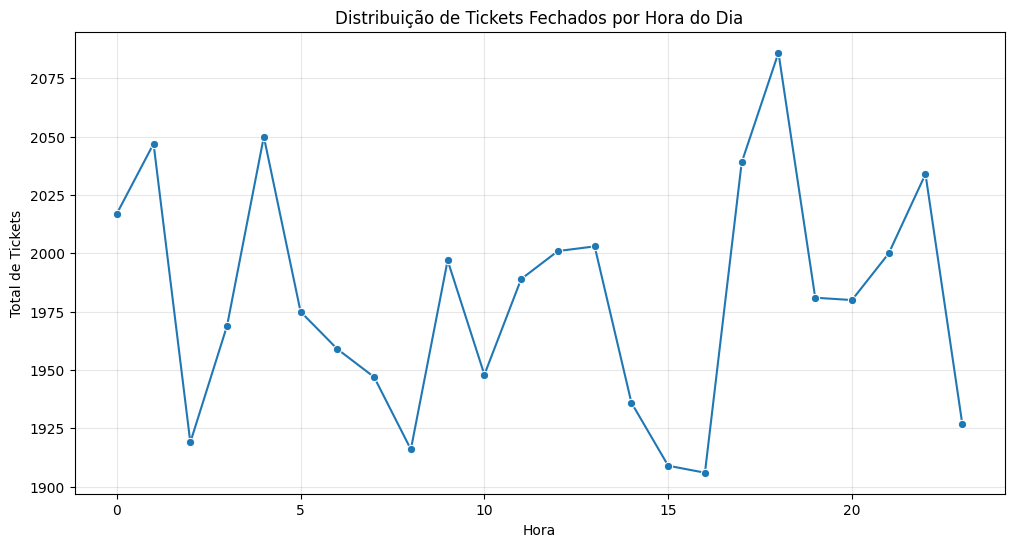

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=tickets_by_hour, x="Hour", y="TotalTickets", marker="o")
plt.title("Distribuição de Tickets Fechados por Hora do Dia")
plt.xlabel("Hora")
plt.ylabel("Total de Tickets")
plt.grid(True, alpha=0.3)
plt.show()

## Sazonalidade

In [16]:
# Análise mensal ao longo dos anos
df_all_closed_dates["YearMonth"] = df_all_closed_dates["ClosedDate"].dt.to_period("M")
monthly_tickets = (
    df_all_closed_dates.groupby("YearMonth")["TotalTickets"].sum().reset_index()
)
monthly_tickets["YearMonth"] = monthly_tickets["YearMonth"].astype(str)

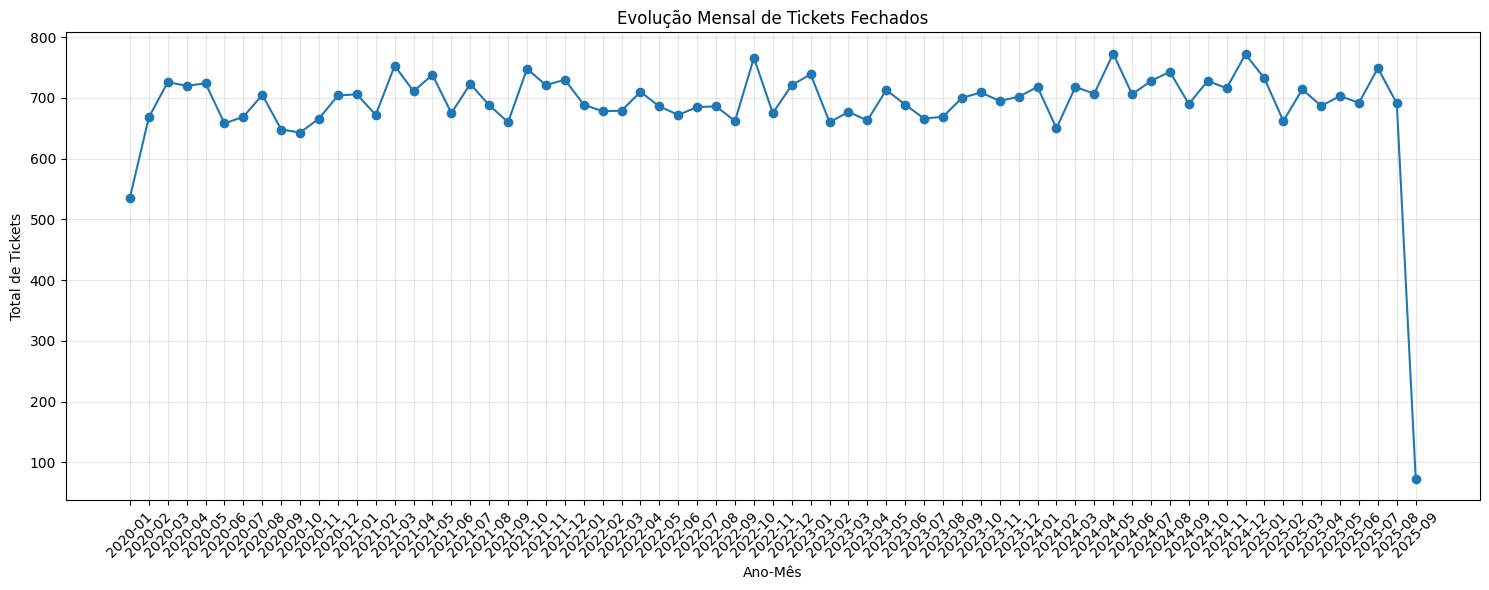

In [17]:
plt.figure(figsize=(15, 6))
plt.plot(monthly_tickets["YearMonth"], monthly_tickets["TotalTickets"], marker="o")
plt.title("Evolução Mensal de Tickets Fechados")
plt.xlabel("Ano-Mês")
plt.ylabel("Total de Tickets")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
df = get_data("../../sql/all_dates2.sql")

In [19]:
# Converter para datetime e definir como índice
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

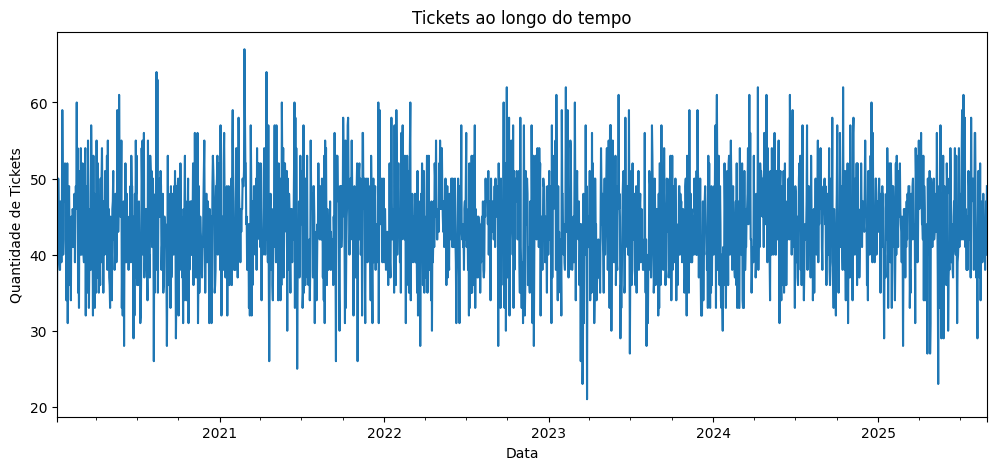

In [20]:
# avaliar a periodicidade dos dados
df["QtTickets"].plot(figsize=(12, 5), title="Tickets ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Quantidade de Tickets")
plt.show()